In [ ]:
!pip install -q timm lxml huggingface_hub

In [ ]:
# https://drive.google.com/file/d/1y_eUNAIKRjkhZiOXJopG4WqJqUguwwaY/view
# !gdown 1y_eUNAIKRjkhZiOXJopG4WqJqUguwwaY
# !unzip -q ICDAR2003.zip -d .

In [ ]:
from lxml import etree
import cv2
import random
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from torchvision import transforms
from torchvision.utils import make_grid
import torch.nn.functional as F
import timm
import time


In [ ]:
def extract_data_from_file(root):
  img_paths = []
  img_sizes = []
  bboxes = []
  labels = []

  for image in root:
    bbox_image  = []
    label_image = []

    img_path = image[0].text
    img_paths.append(img_path)

    img_size = image[1].attrib.values()
    img_size_proccessing = tuple([int(i) for i in img_size])
    img_sizes.append(img_size_proccessing)

    for rectangle in image[2]:
      # fill-data: check non-alphabet and non-number
      if not rectangle[0].text.isalnum():
          continue

      if "é" in rectangle[0].text.lower() or "ñ" in rectangle[0].text.lower():
          continue

      bbox_obj = rectangle.attrib.values()[:-3]
      bbox_processing = [float(i) for i in bbox_obj]
      bbox_image.append(bbox_processing)

      obj_label = rectangle[0].text.lower()
      label_image.append(obj_label)

    bboxes.append(bbox_image)
    labels.append(label_image)

  return img_paths, img_sizes, bboxes, labels

In [ ]:
xml_data = '/content/data/SceneTrialTrain/words.xml'
xml_tree = etree.parse(xml_data)
root = xml_tree.getroot()

img_paths, img_sizes, bboxes, labels = extract_data_from_file(root)
print(img_paths[0], img_sizes[0], bboxes[0], labels[0], sep='\n')

apanar_06.08.2002/IMG_1261.JPG
(1600, 1200)
[[174.0, 392.0, 274.0, 195.0], [512.0, 391.0, 679.0, 183.0], [184.0, 612.0, 622.0, 174.0], [863.0, 599.0, 446.0, 187.0], [72.0, 6.0, 95.0, 87.0], [247.0, 2.0, 197.0, 88.0], [792.0, 0.0, 115.0, 81.0], [200.0, 848.0, 228.0, 139.0], [473.0, 878.0, 165.0, 109.0], [684.0, 878.0, 71.0, 106.0], [806.0, 844.0, 218.0, 141.0]]
['self', 'adhesive', 'address', 'labels', '36', '89m', 'cls', '250', 'on', 'a', 'roll']


In [ ]:
def plot_bboxes_random_img(img_paths, bboxes, data_root='/content/data/SceneTrialTrain'):
  data_len = len(img_paths)
  random_index = random.randint(0, data_len - 1)

  random_img = img_paths[random_index]
  random_img_path = os.path.join(data_root, random_img)
  img = cv2.imread(random_img_path)

  for bbox_object in bboxes[random_index]:
    top_left_x, top_left_y, w, h = bbox_object

    b_r_x = top_left_x + w
    b_r_y = top_left_y + h

    top_left_img = (int(top_left_x), int(top_left_y))
    bottom_right_img = (int(b_r_x), int(b_r_y))
    green_color = (0, 255, 0)
    thickness = 2

    cv2.rectangle(img, top_left_img, bottom_right_img, green_color, thickness)

  plt.imshow(img)
  plt.axis('off')

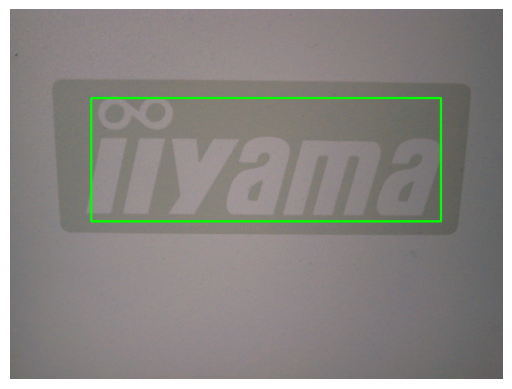

In [ ]:
img = plot_bboxes_random_img(img_paths, bboxes)
img

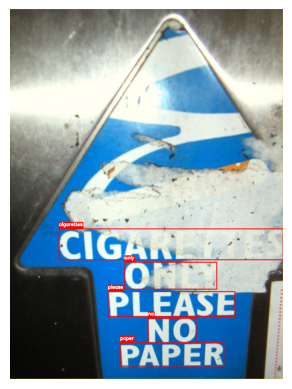

In [ ]:
def plot_image_with_bbs(img_path, bbs, labels):
    img_path = os.path.join('/content/data/SceneTrialTrain', img_path)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    for idx, bb in enumerate(bbs):
        start_point = (int(bb[0]), int(bb[1]))
        end_point = (int(bb[0] + bb[2]), int(bb[1] + bb[3]))
        color = (255, 0, 0)
        thickness = 2
        img = cv2.rectangle(img, start_point, end_point, color, thickness)

        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        font_color = (255, 255, 255)
        line_type = 2
        text_thickness = 2
        label = labels[idx]
        text_size, _ = cv2.getTextSize(label, font, font_scale, text_thickness)

        label_background_start = (int(bb[0]), int(bb[1] - text_size[1] - 10))
        label_background_end = (int(bb[0] + text_size[0]), int(bb[1]))
        img = cv2.rectangle(
            img, label_background_start, label_background_end, color, cv2.FILLED
        )

        cv2.putText(
            img,
            label,
            (int(bb[0]), int(bb[1] - 10)),
            font,
            font_scale,
            font_color,
            text_thickness,
            line_type,
        )

    plt.imshow(img)
    plt.axis("off")
    plt.show()


i = random.randint(0, len(img_paths) - 1)
plot_image_with_bbs(img_paths[i], bboxes[i], labels[i])

In [ ]:
def convert_to_new_dataset(img_paths, bboxes, labels, root='/content/data'):

  old_root_path = os.path.join(root, 'SceneTrialTrain')
  object_log = []
  count = 0

  new_dataset_root = os.path.join(root, 'new_data')
  os.makedirs(new_dataset_root, exist_ok=True)

  new_img_path = os.path.join(new_dataset_root, 'images')
  os.makedirs(new_img_path, exist_ok=True)

  new_label_path = os.path.join(new_dataset_root, 'labels')
  os.makedirs(new_label_path, exist_ok=True)

  for i in range(len(img_paths)):
    sample = os.path.join(old_root_path, img_paths[i])
    sample_bbox = bboxes[i]
    sample_label = labels[i]
    img = Image.open(sample)

    for object_bbox, label_bbox in zip(sample_bbox, sample_label):
      # check length
      if len(sample_bbox) != len(sample_label):
        raise ValueError(f"Mismatch at index {i}: {len(sample_bbox)} bboxes vs {len(sample_label)} labels")

      left, top_left_y, w, h = object_bbox
      x_left_side = left
      x_right_side = left + w
      y_top_side = top_left_y
      y_bottom_side = y_top_side + h

      bbox_object_pillow_format = (x_left_side, y_top_side, x_right_side, y_bottom_side)

      crop_img = img.crop(bbox_object_pillow_format)

      # filter out if 90% of the cropped image is black or white
      if np.mean(crop_img) < 35 or np.mean(crop_img) > 220:
          continue
      if crop_img.size[0] < 10 or crop_img.size[1] < 10:
          continue

      new_sample_path = os.path.join(new_img_path, f'{count:06d}.jpg')
      crop_img.save(new_sample_path)
      count = count + 1

      img_path = new_sample_path.split('/')[-3:]
      img_path = os.path.join(*img_path)

      object_log.append(f'{img_path}\t{label_bbox}\n')


  # file logging
  print(f"Crop {count} objects.")
  with open(os.path.join(new_label_path, 'labels.txt'), 'w') as file:
    for line in object_log:
      file.write(line)



In [ ]:
convert_to_new_dataset(img_paths, bboxes, labels)

Crop 1088 objects.


In [ ]:
def read_label_file(label_file_path='/content/data/new_data/labels/labels.txt'):
  X = []
  y = []

  with open(label_file_path, 'r') as file:
    text_lines = file.readlines()

  text_lines_escape_removal =  [line[:-1] for line in text_lines]
  for line in text_lines_escape_removal:
    obj_sample = line.split('\t')
    X_obj, y_obj = obj_sample

    X.append(X_obj)
    y.append(y_obj)

  return X, y

In [ ]:
X, y = read_label_file()
print(X[:5])
print(y[:5])

['new_data/images/000000.jpg', 'new_data/images/000001.jpg', 'new_data/images/000002.jpg', 'new_data/images/000003.jpg', 'new_data/images/000004.jpg']
['self', 'adhesive', 'address', 'labels', '36']


In [ ]:
def get_vocab(y):
  char_vocab = ''.join(sorted(set(''.join(y))))
  char_vocab = '-' + char_vocab
  label2idx = {char: idx + 1 for idx, char in enumerate(char_vocab)}
  idx2label = {idx: label for label, idx in label2idx.items()}

  return label2idx, idx2label

In [ ]:
label_2_idx, idx_2_label = get_vocab(y)
print(label_2_idx)
print(idx_2_label)

{'-': 1, '0': 2, '1': 3, '2': 4, '3': 5, '4': 6, '5': 7, '6': 8, '7': 9, '8': 10, '9': 11, 'a': 12, 'b': 13, 'c': 14, 'd': 15, 'e': 16, 'f': 17, 'g': 18, 'h': 19, 'i': 20, 'j': 21, 'k': 22, 'l': 23, 'm': 24, 'n': 25, 'o': 26, 'p': 27, 'q': 28, 'r': 29, 's': 30, 't': 31, 'u': 32, 'v': 33, 'w': 34, 'x': 35, 'y': 36, 'z': 37}
{1: '-', 2: '0', 3: '1', 4: '2', 5: '3', 6: '4', 7: '5', 8: '6', 9: '7', 10: '8', 11: '9', 12: 'a', 13: 'b', 14: 'c', 15: 'd', 16: 'e', 17: 'f', 18: 'g', 19: 'h', 20: 'i', 21: 'j', 22: 'k', 23: 'l', 24: 'm', 25: 'n', 26: 'o', 27: 'p', 28: 'q', 29: 'r', 30: 's', 31: 't', 32: 'u', 33: 'v', 34: 'w', 35: 'x', 36: 'y', 37: 'z'}


In [ ]:
MAX_LABEL_LEN = max(len(l) for l in y)
def encode(label, label2idx):
  len_sample = len(label)
  sample_transfer = torch.tensor([label2idx[char] for char in list(label)])
  max_len_label = MAX_LABEL_LEN

  num_zero_padding = max_len_label - len(label)
  sample_padding = F.pad(sample_transfer, (0, num_zero_padding), 'constant', value=0)

  return sample_padding, len_sample

In [ ]:
encode(y[5], label_2_idx)

(tensor([4, 7, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]), 3)

In [ ]:
data_transforms = {
    "train": transforms.Compose(
        [
            transforms.Resize((100, 420)),
            transforms.ColorJitter(
                brightness=0.5,
                contrast=0.5,
                saturation=0.5,
            ),
            transforms.Grayscale(
                num_output_channels=1,
            ),
            transforms.GaussianBlur(3),
            transforms.RandomAffine(
                degrees=2,
                shear=2,
            ),
            transforms.RandomPerspective(
                distortion_scale=0.3,
                p=0.5,
                interpolation=3,
            ),
            transforms.RandomRotation(degrees=2),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    ),
    "val": transforms.Compose(
        [
            transforms.Resize((100, 420)),
            transforms.Grayscale(num_output_channels=1),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),
        ]
    ),
}

In [ ]:
val_ratio = 0.1
test_ratio = 0.1

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=val_ratio, random_state=0, shuffle=True)
X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=test_ratio, random_state=0, shuffle=True)

print(f'train set: {len(X_train)}')
print(f'val set: {len(X_val)}')
print(f'test set: {len(X_test)}')

train set: 881
val set: 109
test set: 98


In [ ]:
class TextRecognitionDataset(Dataset):
  def __init__(self, X, y, vocab, transform, encoder, root_data='/content/data'):
    super().__init__()
    self.X = X
    self.y = y
    self.vocab = vocab
    self.encoder = encoder
    self.transform = transform
    self.root_data = root_data

  def __len__(self):
    return len(self.X)

  def __getitem__(self, index):
    label = self.y[index]
    img_path = os.path.join(self.root_data, self.X[index])
    img = Image.open(img_path).convert("RGB")

    label_transform, label_len = self.encoder(label, self.vocab)
    if self.transform:
      img = self.transform(img)
    return img, label_transform, label_len

trainset = TextRecognitionDataset(X_train, y_train, label_2_idx, data_transforms["train"], encode)
valset = TextRecognitionDataset(X_val, y_val, label_2_idx, data_transforms["val"], encode)
testset = TextRecognitionDataset(X_test, y_test, label_2_idx, data_transforms["val"], encode)

print(trainset.__len__())
print(valset.__len__())
print(testset.__len__())

881
109
98


In [ ]:
train_batch_size = 64
val_batch_size = 16
test_batch_size = 16

trainloader = DataLoader(
    trainset,
    batch_size=train_batch_size,
    shuffle=True,
)

valloader = DataLoader(
    valset,
    batch_size=val_batch_size,
    shuffle=False,
)

testloader = DataLoader(
    testset,
    batch_size=test_batch_size,
    shuffle=False,
)

print(trainloader.batch_size)
print(valloader.batch_size)
print(testloader.batch_size)

64
16
16


In [ ]:
def decode(encoded_sequences, idx_to_char, blank_char="-"):
    decoded_sequences = []

    for seq in encoded_sequences:
        decoded_label = []
        prev_char = None

        for token in seq:
            if token != 0:
                char = idx_to_char[token.item()]
                if char != blank_char:
                    if char != prev_char or prev_char == blank_char:
                        decoded_label.append(char)
                prev_char = char

        decoded_sequences.append("".join(decoded_label))

    return decoded_sequences

X_batch_plot, y_batch_plot, label_len = next(iter(trainloader))
decode(y_batch_plot[:5], idx_2_label)

['hardware', 'kep', 'viglen', 't', 'discusion']

['hardware', 'kep', 'viglen', 't', 'discusion', 'criminal', 'hsbc', 'soap', 'to', 'o', 'ales', 'maintenance', 'up', 'way', 'tetley', 'knes', 'pronto', 'ride', 'comonwealth', 'java', 'id', 'profesional', 'fluoride', 'yds', 'walace', 'renault', 'flor', 'series', 'central', 'imported', 'toilet', 'trespasing', 'colmint', '820e', 'yarmouth', 'ofice', 'cros', 'specialties', 'word', 'town', 'of', 'the', 'limited', '7', 'esex', 'bot', 'aligator', 'orange', 'liquid', 'programing', '59', 'extra', 'scrol', 'final', 'stop', 'inspiron', 'of', 'walace', 'savers', 'osborne', '2', 'iyama', 'animal', 'ofice']


(np.float64(-0.5), np.float64(1689.5), np.float64(1633.5), np.float64(-0.5))

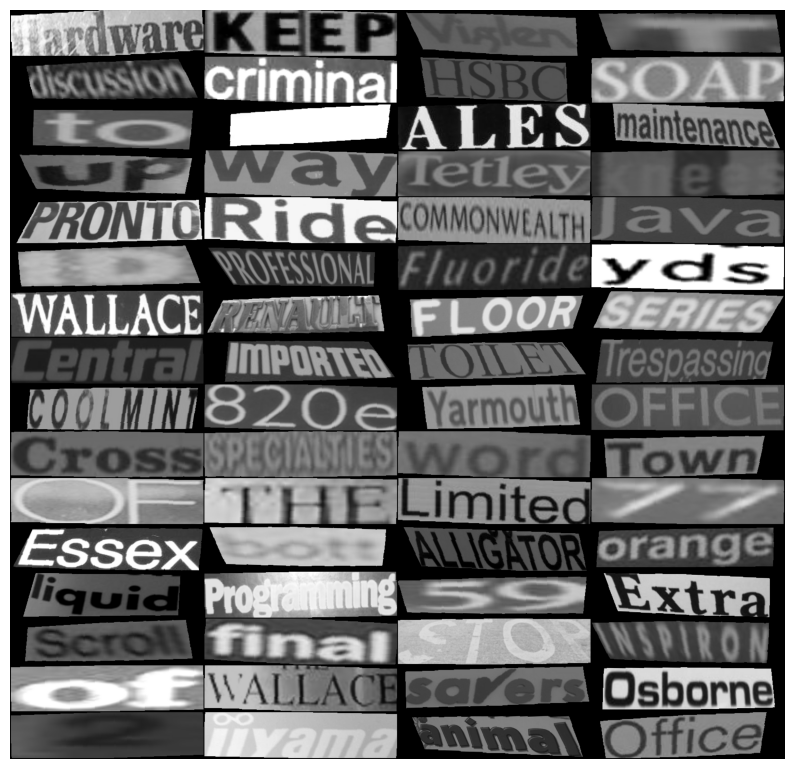

In [ ]:
labels = decode(y_batch_plot, idx_2_label)
grid = make_grid(X_batch_plot, nrow=4, normalize=True)
print(labels)

# plot
plt.figure(figsize=(10, 20))
plt.imshow(np.transpose(grid, (1, 2, 0)))
plt.axis("off")

In [ ]:
class CRNNModel(nn.Module):
  def __init__(self, vocab_size, emb_dim=512, hidden_size=256, dropout_prob=0.2, num_layers=3, unfreeze_layer=3):
    super().__init__()

    # backbone CNN
    cnn_model = timm.create_model('resnet34', pretrained=True, in_chans=1)
    cnn_model_classifier_removal = list(cnn_model.children())[:-2]
    cnn_model_classifier_removal.append(nn.AdaptiveAvgPool2d((1, None)))
    cnn_model_standard_type = nn.Sequential(*cnn_model_classifier_removal)
    self.backbone = cnn_model_standard_type


    for param in self.backbone[-unfreeze_layer:].parameters():
      param.requires_grad = True

    self.linear_layer = nn.Sequential(
        nn.Linear(512, emb_dim),
        nn.ReLU(),
        nn.Dropout(dropout_prob)
    )

    self.rnn_layer = nn.GRU(
        input_size=emb_dim,
        hidden_size=hidden_size,
        bidirectional=True,
        batch_first=True,
        num_layers=num_layers,
        dropout=dropout_prob if num_layers > 1 else 0
    )

    self.layernorm = nn.LayerNorm(hidden_size*2)

    self.output = nn.Sequential(
        nn.Linear(hidden_size*2, vocab_size + 1),
        nn.LogSoftmax(dim=2)
    )

  @torch.autocast(device_type="cuda")
  def forward(self, x):
    x = self.backbone(x)
    x = x.permute(0, 3, 1, 2)
    x = x.view(x.size(0), x.size(1), -1)
    x = self.linear_layer(x)
    x, _ = self.rnn_layer(x)
    x = self.layernorm(x)
    x = self.output(x)
    x = x.permute(1, 0, 2)  # CTC: (input_length, batch_size, num_classes)
    return x

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
vocab_size = len(idx_2_label)
crnn_model = CRNNModel(vocab_size).to(device)
print(list(crnn_model.children())[-4:])

[Sequential(
  (0): Linear(in_features=512, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.2, inplace=False)
), GRU(512, 256, num_layers=3, batch_first=True, dropout=0.2, bidirectional=True), LayerNorm((512,), eps=1e-05, elementwise_affine=True), Sequential(
  (0): Linear(in_features=512, out_features=38, bias=True)
  (1): LogSoftmax(dim=2)
)]


In [ ]:
# config hyperparameter
lr = 0.001
w_decay = 1e-5
epochs = 100
scheduler = epochs * 0.5

criterion = nn.CTCLoss(
    blank= label_2_idx['-'],
    reduction='mean',
    zero_infinity=True
)

optimizer = torch.optim.Adam(
    crnn_model.parameters(),
    lr=lr,
    weight_decay=w_decay
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=scheduler,
    gamma=0.5
)

In [ ]:
import time
import torch

def fit(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    device,
    epochs,
    max_grad_norm=2,
    patience=30,
    min_delta=0.001,
):
    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    early_stop_counter = 0

    for epoch in range(epochs):
        start = time.time()

        batch_train_losses = []

        model.train()
        for idx, (inputs, labels, labels_len) in enumerate(train_loader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            labels_len = labels_len.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)

            logits_lens = torch.full(
                size=(outputs.size(1),),
                fill_value=outputs.size(0),
                dtype=torch.long,
            ).to(device)

            loss = criterion(outputs, labels.cpu(), logits_lens.cpu(), labels_len.cpu())

            loss.backward()

            # Gradient clipping with a configurable max norm
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

            optimizer.step()

            batch_train_losses.append(loss.item())

        train_loss = sum(batch_train_losses) / len(batch_train_losses)
        train_losses.append(train_loss)

        val_loss = evaluate(model, val_loader, criterion, device)
        val_losses.append(val_loss)

        print(
            f"EPOCH {epoch + 1}:\tTrain loss: {train_loss:.4f}\tVal loss: {val_loss:.4f}\t\t Time: {time.time() - start:.2f} seconds"
        )

        scheduler.step()

        # Early stopping
        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            if early_stop_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch + 1}")
                break

    return train_losses, val_losses

In [ ]:
def evaluate(model, dataloader, criterion, device):
    model.eval()
    losses = []
    with torch.no_grad():
        for idx, (inputs, labels, labels_len) in enumerate(dataloader):
            inputs = inputs.to(device)
            labels = labels.to(device)
            labels_len = labels_len.to(device)

            outputs = model(inputs)
            logits_lens = torch.full(
                size=(outputs.size(1),), fill_value=outputs.size(0), dtype=torch.long
            ).to(device)

            # Print some samples after decoding
            # if idx == 0:
            #     print(decode(outputs.permute(1, 0, 2).argmax(2), idx_to_char)[:10])
            #     print(decode(labels, idx_to_char)[:10])

            loss = criterion(outputs, labels, logits_lens, labels_len)
            losses.append(loss.item())

    loss = sum(losses) / len(losses)

    return loss

In [ ]:
train_losses, val_losses = fit(crnn_model, trainloader, valloader, criterion, optimizer, scheduler, device, epochs)

EPOCH 1:	Train loss: 4.4268	Val loss: 3.9242		 Time: 5.69 seconds
EPOCH 2:	Train loss: 3.6123	Val loss: 3.5840		 Time: 6.07 seconds
EPOCH 3:	Train loss: 3.4365	Val loss: 3.6194		 Time: 5.93 seconds
EPOCH 4:	Train loss: 3.3423	Val loss: 3.5697		 Time: 5.82 seconds
EPOCH 5:	Train loss: 3.2240	Val loss: 3.0529		 Time: 5.82 seconds
EPOCH 6:	Train loss: 2.9347	Val loss: 3.1054		 Time: 5.96 seconds
EPOCH 7:	Train loss: 2.6424	Val loss: 2.7041		 Time: 6.39 seconds
EPOCH 8:	Train loss: 2.2401	Val loss: 2.5283		 Time: 5.83 seconds
EPOCH 9:	Train loss: 1.8414	Val loss: 2.1126		 Time: 5.74 seconds
EPOCH 10:	Train loss: 1.5867	Val loss: 1.7787		 Time: 5.74 seconds
EPOCH 11:	Train loss: 1.3329	Val loss: 1.5254		 Time: 5.74 seconds
EPOCH 12:	Train loss: 1.1112	Val loss: 1.2446		 Time: 6.18 seconds
EPOCH 13:	Train loss: 0.8963	Val loss: 1.3839		 Time: 5.74 seconds
EPOCH 14:	Train loss: 0.8080	Val loss: 1.2138		 Time: 5.78 seconds
EPOCH 15:	Train loss: 0.7126	Val loss: 1.0923		 Time: 5.75 seconds
EPOC

In [ ]:
val_loss = evaluate(crnn_model, valloader, criterion, device)
test_loss = evaluate(crnn_model, testloader, criterion, device)

print("Evaluation on val/test dataset")
print("Val loss: ", val_loss)
print("Test loss: ", test_loss)

Evaluation on val/test dataset
Val loss:  0.9654215744563511
Test loss:  1.0664703505379813


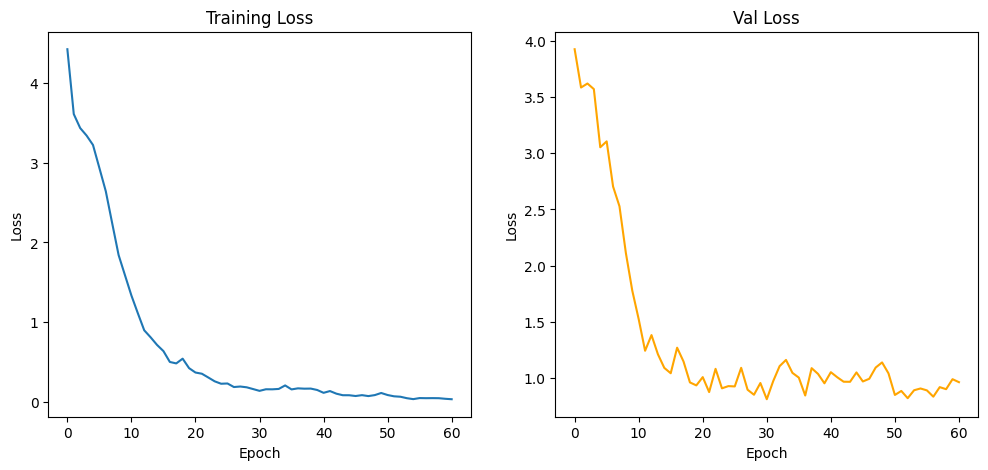

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].plot(train_losses)
ax[0].set_title("Training Loss")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Loss")
ax[1].plot(val_losses, color="orange")
ax[1].set_title("Val Loss")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Loss")
plt.show()

In [ ]:
def predict(model, img):
    model.eval()
    with torch.no_grad():
        outputs = model(img)
        print(outputs)
        pred = decode(outputs.permute(1, 0, 2).argmax(2), idx_2_label)
        return pred



def decode_label(encoded_sequences, idx_to_char, blank_char="-"):
    decoded_sequences = []

    for seq in encoded_sequences:
        decoded_label = []
        for idx, token in enumerate(seq):
            if token != 0:
                char = idx_to_char[token.item()]
                if char != blank_char:
                    decoded_label.append(char)

        decoded_sequences.append("".join(decoded_label))

    return decoded_sequences

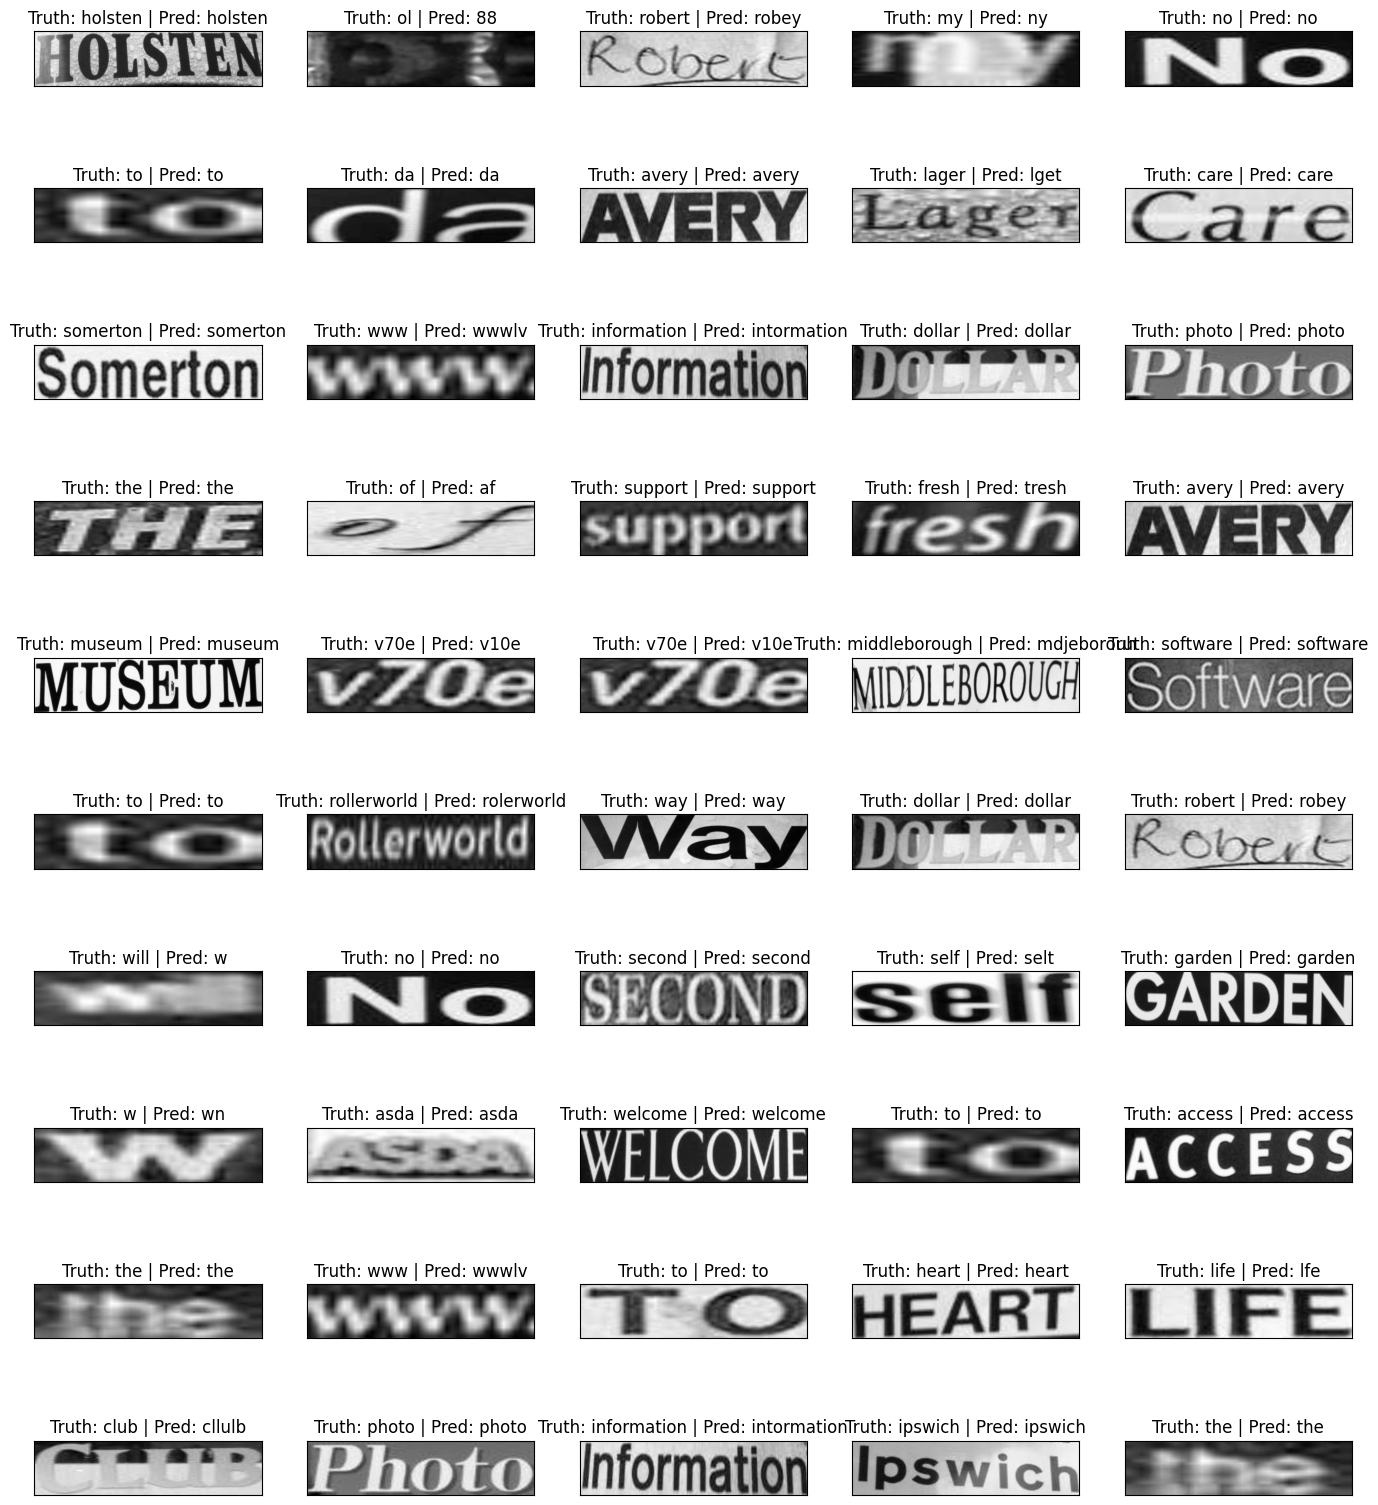

In [ ]:
# view samples
sample_result = []

for i in range(50):
    idx = np.random.randint(len(testset))
    img, label, label_len = testset[idx]
    img = img.to(device)
    label = label.to(device)
    label = decode_label([label], idx_2_label)[0]
    logits = crnn_model(img.unsqueeze(0))

    pred_text = decode(logits.permute(1, 0, 2).argmax(2), idx_2_label)[0]

    sample_result.append((img, label, pred_text))

fig = plt.figure(figsize=(17, 20))
for i in range(50):
    ax = fig.add_subplot(10, 5, i + 1, xticks=[], yticks=[])

    img, label, pred_text = sample_result[i]
    img = img.cpu()
    title = f"Truth: {label} | Pred: {pred_text}"

    ax.imshow(img.permute(1, 2, 0), cmap="gray")
    ax.set_title(title)

plt.show()

In [ ]:
save_model_path = "ocr_crnn.pt"
torch.save(crnn_model.state_dict(), save_model_path)